# ============================================================
# 🍄 MUSHROOM EDIBILITY CLASSIFICATION - ML PIPELINE
# ============================================================
# Problem: Predict whether a mushroom is EDIBLE or POISONOUS
# Type: BINARY CLASSIFICATION
# ============================================================

In [1]:
# ============================================================
# STEP 1.1: IMPORTING ALL LIBRARIES AT ONCE
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
# ============================================================
# STEP 2: LOAD DATASET
# ============================================================
df = pd.read_csv('Mushroom_Edibility.csv')
print(f"Shape: {df.shape}")

Shape: (8416, 23)


In [3]:
# ============================================================
# STEP 3: INSPECT DATA
# ============================================================
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,EDIBLE,CONVEX,SMOOTH,WHITE,BRUISES,ALMOND,FREE,CROWDED,NARROW,WHITE,...,SMOOTH,WHITE,WHITE,PARTIAL,WHITE,ONE,PENDANT,PURPLE,SEVERAL,WOODS
1,EDIBLE,CONVEX,SMOOTH,WHITE,BRUISES,ALMOND,FREE,CROWDED,NARROW,WHITE,...,SMOOTH,WHITE,WHITE,PARTIAL,WHITE,ONE,PENDANT,BROWN,SEVERAL,WOODS
2,EDIBLE,CONVEX,SMOOTH,WHITE,BRUISES,ALMOND,FREE,CROWDED,NARROW,PINK,...,SMOOTH,WHITE,WHITE,PARTIAL,WHITE,ONE,PENDANT,PURPLE,SEVERAL,WOODS
3,EDIBLE,CONVEX,SMOOTH,WHITE,BRUISES,ALMOND,FREE,CROWDED,NARROW,PINK,...,SMOOTH,WHITE,WHITE,PARTIAL,WHITE,ONE,PENDANT,BROWN,SEVERAL,WOODS
4,EDIBLE,CONVEX,SMOOTH,WHITE,BRUISES,ALMOND,FREE,CROWDED,NARROW,BROWN,...,SMOOTH,WHITE,WHITE,PARTIAL,WHITE,ONE,PENDANT,PURPLE,SEVERAL,WOODS


In [4]:
df.dtypes

class                       str
cap-shape                   str
cap-surface                 str
cap-color                   str
bruises                     str
odor                        str
gill-attachment             str
gill-spacing                str
gill-size                   str
gill-color                  str
stalk-shape                 str
stalk-root                  str
stalk-surface-above-ring    str
stalk-surface-below-ring    str
stalk-color-above-ring      str
stalk-color-below-ring      str
veil-type                   str
veil-color                  str
ring-number                 str
ring-type                   str
spore-print-color           str
population                  str
habitat                     str
dtype: object

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8416 entries, 0 to 8415
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8416 non-null   str  
 1   cap-shape                 8416 non-null   str  
 2   cap-surface               8416 non-null   str  
 3   cap-color                 8416 non-null   str  
 4   bruises                   8416 non-null   str  
 5   odor                      8416 non-null   str  
 6   gill-attachment           8416 non-null   str  
 7   gill-spacing              8416 non-null   str  
 8   gill-size                 8416 non-null   str  
 9   gill-color                8416 non-null   str  
 10  stalk-shape               8416 non-null   str  
 11  stalk-root                8416 non-null   str  
 12  stalk-surface-above-ring  8416 non-null   str  
 13  stalk-surface-below-ring  8416 non-null   str  
 14  stalk-color-above-ring    8416 non-null   str  
 15

In [6]:
df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8416,8416,8416,8416,8416,8416,8416,8416,8416,8416,...,8416,8416,8416,8416,8416,8416,8416,8416,8416,8416
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,EDIBLE,CONVEX,SCALY,BROWN,NO,NONE,FREE,CLOSE,BROAD,BUFF,...,SMOOTH,WHITE,WHITE,PARTIAL,WHITE,ONE,PENDANT,WHITE,SEVERAL,WOODS
freq,4488,3796,3268,2320,5040,3808,8200,6824,5880,1728,...,5076,4744,4640,8416,8216,7768,3968,2424,4064,3160


In [7]:
df['class'].value_counts()

class
EDIBLE       4488
POISONOUS    3928
Name: count, dtype: int64

In [8]:
# Missing values
missing = df.isnull().sum()
print(missing if missing.any() else "No missing values found!")

No missing values found!


In [9]:
# ============================================================
# STEP 4: CLEAN DATA
# ============================================================
print(df.isnull().sum())
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"After cleaning: {df.shape}")
df

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64
After cleaning: (8124, 23)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,EDIBLE,CONVEX,SMOOTH,WHITE,BRUISES,ALMOND,FREE,CROWDED,NARROW,WHITE,...,SMOOTH,WHITE,WHITE,PARTIAL,WHITE,ONE,PENDANT,PURPLE,SEVERAL,WOODS
1,EDIBLE,CONVEX,SMOOTH,WHITE,BRUISES,ALMOND,FREE,CROWDED,NARROW,WHITE,...,SMOOTH,WHITE,WHITE,PARTIAL,WHITE,ONE,PENDANT,BROWN,SEVERAL,WOODS
2,EDIBLE,CONVEX,SMOOTH,WHITE,BRUISES,ALMOND,FREE,CROWDED,NARROW,PINK,...,SMOOTH,WHITE,WHITE,PARTIAL,WHITE,ONE,PENDANT,PURPLE,SEVERAL,WOODS
3,EDIBLE,CONVEX,SMOOTH,WHITE,BRUISES,ALMOND,FREE,CROWDED,NARROW,PINK,...,SMOOTH,WHITE,WHITE,PARTIAL,WHITE,ONE,PENDANT,BROWN,SEVERAL,WOODS
4,EDIBLE,CONVEX,SMOOTH,WHITE,BRUISES,ALMOND,FREE,CROWDED,NARROW,BROWN,...,SMOOTH,WHITE,WHITE,PARTIAL,WHITE,ONE,PENDANT,PURPLE,SEVERAL,WOODS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,EDIBLE,KNOBBED,SMOOTH,BROWN,NO,NONE,ATTACHED,CLOSE,BROAD,BROWN,...,SMOOTH,ORANGE,ORANGE,PARTIAL,BROWN,ONE,PENDANT,BROWN,CLUSTERED,LEAVES
8120,EDIBLE,KNOBBED,SMOOTH,BROWN,NO,NONE,ATTACHED,CLOSE,BROAD,BROWN,...,SMOOTH,ORANGE,ORANGE,PARTIAL,BROWN,ONE,PENDANT,ORANGE,SEVERAL,LEAVES
8121,EDIBLE,KNOBBED,SMOOTH,BROWN,NO,NONE,ATTACHED,CLOSE,BROAD,BROWN,...,SMOOTH,ORANGE,ORANGE,PARTIAL,BROWN,ONE,PENDANT,ORANGE,CLUSTERED,LEAVES
8122,EDIBLE,KNOBBED,SMOOTH,BROWN,NO,NONE,ATTACHED,CLOSE,BROAD,BROWN,...,SMOOTH,ORANGE,ORANGE,PARTIAL,BROWN,ONE,PENDANT,BUFF,SEVERAL,LEAVES


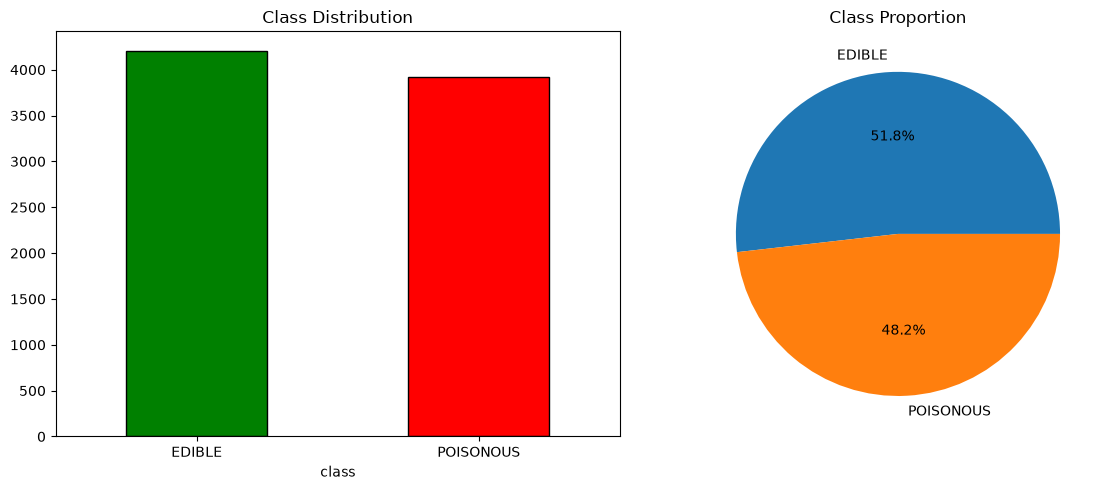

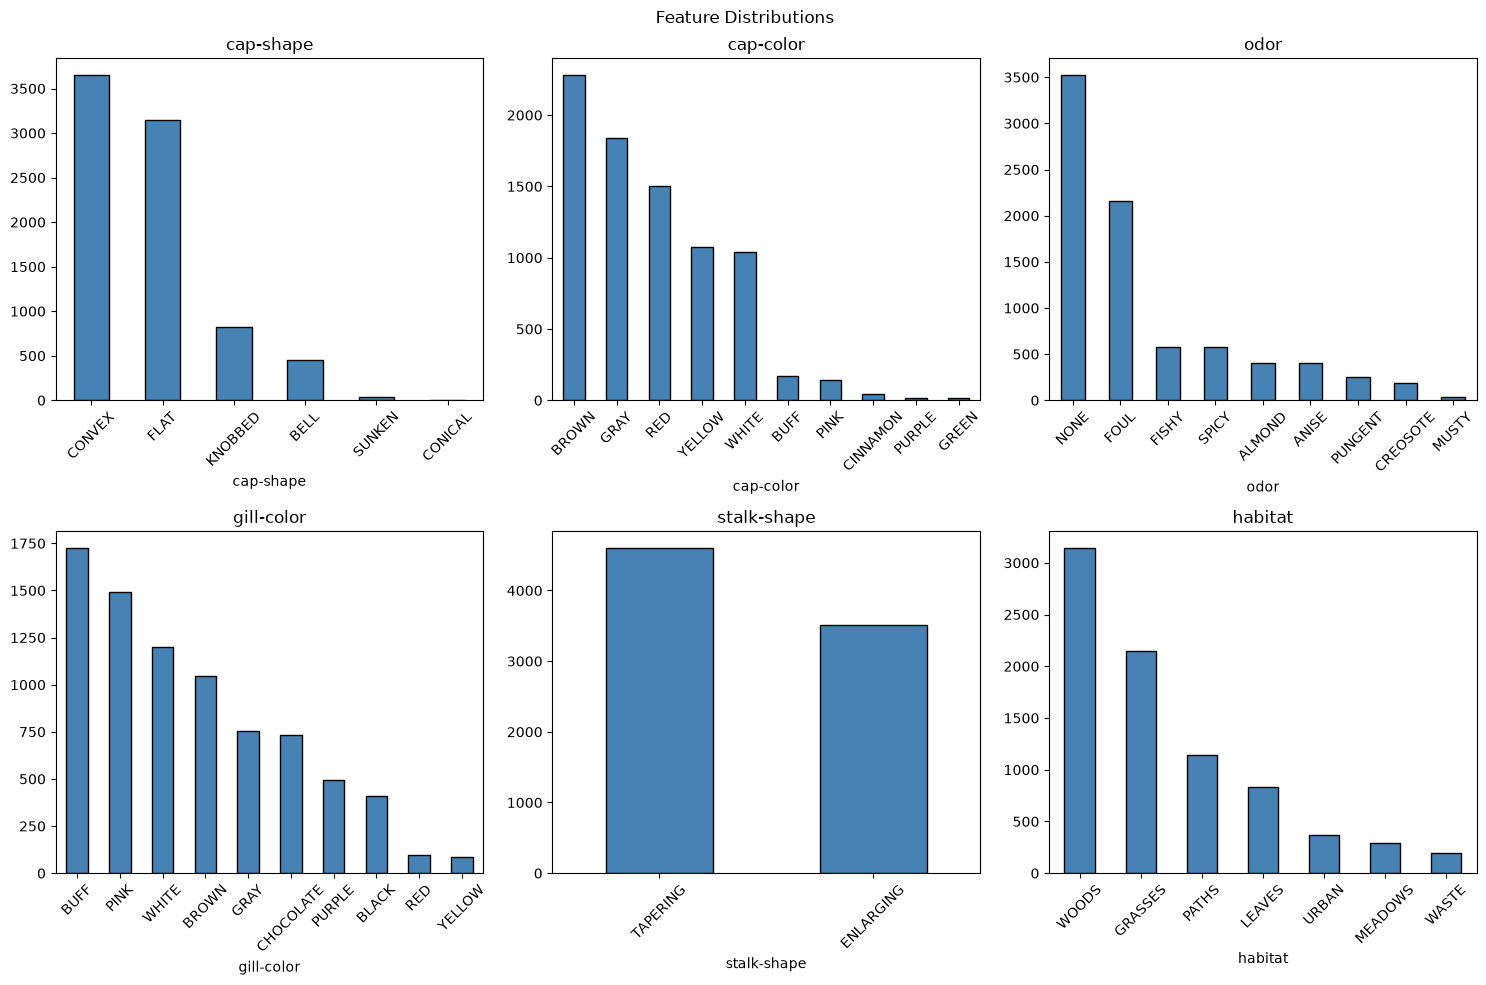

<Figure size 1000x600 with 0 Axes>

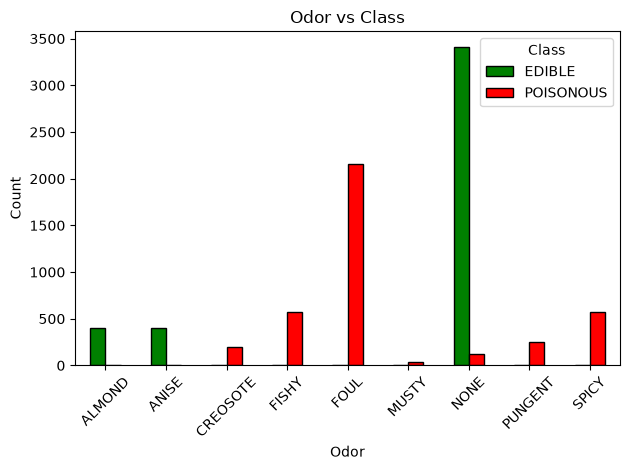

In [10]:
# ============================================================
# STEP 5: EDA (3 plots before encoding)
# ============================================================

# PLOT 1: Target Balance
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['class'].value_counts().plot(kind='bar', ax=axes[0],
                                color=['green', 'red'], edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['EDIBLE', 'POISONOUS'], rotation=0)

df['class'].value_counts().plot(kind='pie', ax=axes[1],
                                color=['green', 'red'], autopct='%1.1f%%')
axes[1].set_title('Class Proportion')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# PLOT 2: Feature Distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features_to_plot = ['cap-shape', 'cap-color', 'odor',
                    'gill-color', 'stalk-shape', 'habitat']

for idx, feature in enumerate(features_to_plot):
    ax = axes[idx // 3, idx % 3]
    df[feature].value_counts().head(10).plot(kind='bar', ax=ax,
                                             color='steelblue', edgecolor='black')
    ax.set_title(feature)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Feature Distributions')
plt.tight_layout()
plt.show()

# PLOT 3: Odor vs Class
plt.figure(figsize=(10, 6))
pd.crosstab(df['odor'], df['class']).plot(kind='bar',
                                          color=['green', 'red'],
                                          edgecolor='black')
plt.title('Odor vs Class')
plt.xlabel('Odor')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Class')
plt.tight_layout()
plt.show()

In [11]:

# ============================================================
# STEP 6: PREPROCESS - ENCODE CATEGORICAL FEATURES
# ============================================================
X = df.drop('class', axis=1)
y = df['class']

# Encode target variable
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

# Encode all categorical features
label_encoders = {}
X_encoded = X.copy()
for col in X_encoded.columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
    label_encoders[col] = le

X_encoded

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,2,3,8,0,0,1,1,1,10,1,...,3,7,7,0,2,1,4,6,4,6
1,2,3,8,0,0,1,1,1,10,1,...,3,7,7,0,2,1,4,1,4,6
2,2,3,8,0,0,1,1,1,7,1,...,3,7,7,0,2,1,4,6,4,6
3,2,3,8,0,0,1,1,1,7,1,...,3,7,7,0,2,1,4,1,4,6
4,2,3,8,0,0,1,1,1,1,1,...,3,7,7,0,2,1,4,6,4,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,4,3,0,1,6,0,0,0,1,0,...,3,4,4,0,0,1,4,1,1,1
8120,4,3,0,1,6,0,0,0,1,0,...,3,4,4,0,0,1,4,5,4,1
8121,4,3,0,1,6,0,0,0,1,0,...,3,4,4,0,0,1,4,5,1,1
8122,4,3,0,1,6,0,0,0,1,0,...,3,4,4,0,0,1,4,2,4,1


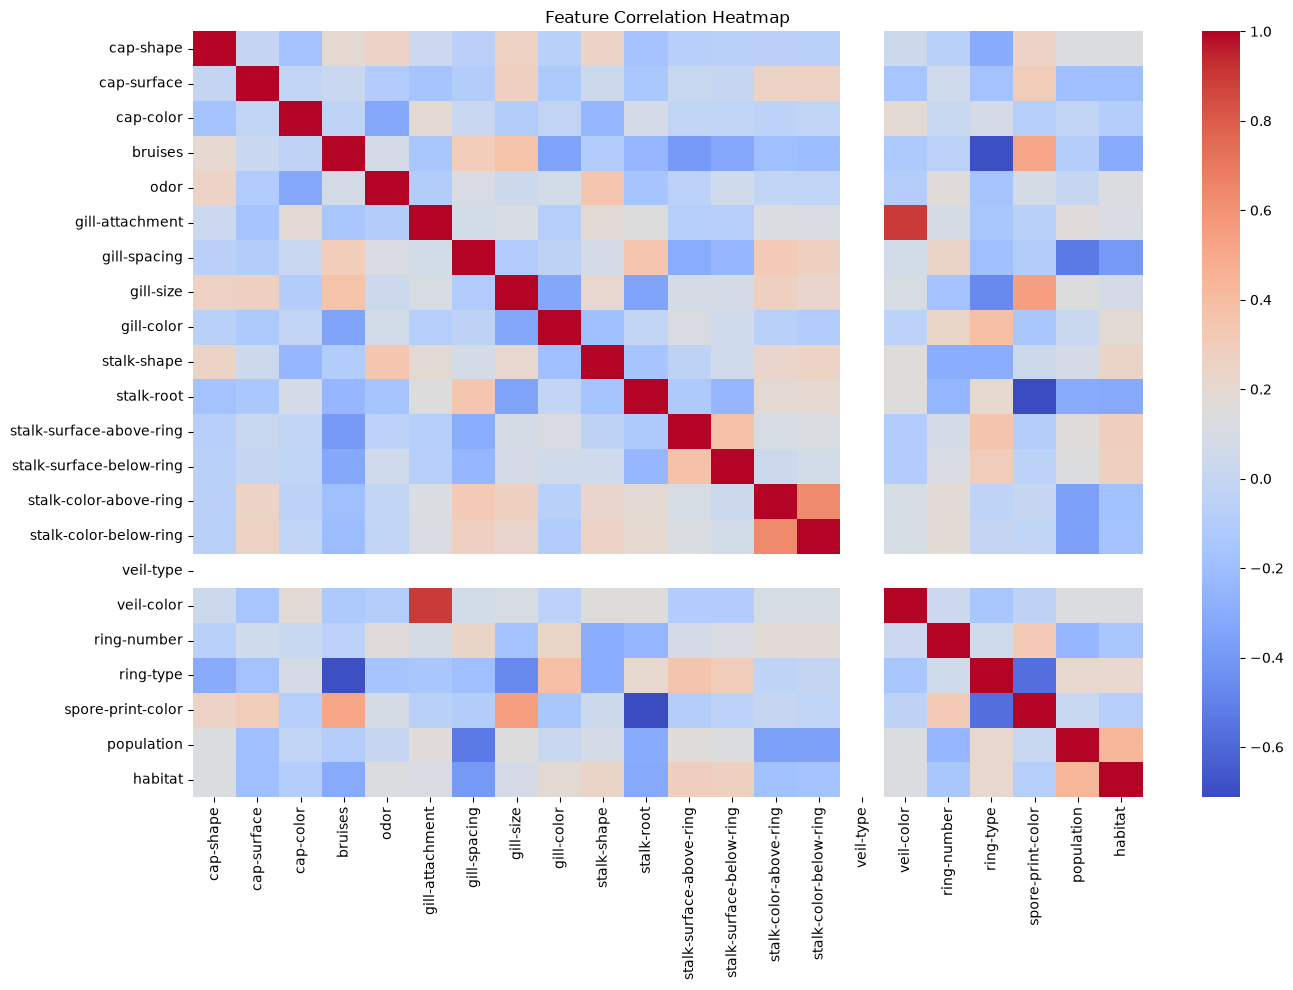

In [12]:
# PLOT 4: Correlation Heatmap (after encoding)
plt.figure(figsize=(14, 10))
sns.heatmap(X_encoded.corr(), cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [13]:

# Scaling (optional for tree-based, important for SVM/KNN/LR)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)
X_scaled = pd.DataFrame(X_scaled, columns=X_encoded.columns)


In [14]:
# ============================================================
# STEP 7: SPLIT DATA INTO TRAIN/TEST
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [15]:

# ============================================================
# STEP 8 & 9: DEFINE & TRAIN MODELS
# ============================================================

# Define all 7 models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVC': SVC(kernel='rbf', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Gaussian Naive Bayes': GaussianNB()
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    results[name] = acc
    print(f"{name:25s} → Accuracy: {acc:.4f}")

Logistic Regression       → Accuracy: 0.9502
Decision Tree             → Accuracy: 1.0000
Random Forest             → Accuracy: 1.0000
SVC                       → Accuracy: 1.0000
KNN                       → Accuracy: 1.0000
Gradient Boosting         → Accuracy: 1.0000
Gaussian Naive Bayes      → Accuracy: 0.8634


In [18]:

# ============================================================
# STEP 10: FINAL RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
results_df.index += 1
best = max(results, key=results.get)
results_df['Best'] = results_df['Model'].apply(lambda x: '⭐' if x == best else '')
results_df

,Model,Accuracy,Best
1,Decision Tree,1.000000,⭐
2,Random Forest,1.000000,
3,SVC,1.000000,
4,KNN,1.000000,
5,Gradient Boosting,1.000000,
6,Logistic Regression,0.950154,
7,Gaussian Naive Bayes,0.863385,


In [ ]:

# Save to CSV
results_df.to_csv('model_comparison_results.csv', index=False)
print("\n✅ Results saved to: model_comparison_results.csv")


✅ Results saved to: model_comparison_results.csv
